# Loading and analyzing the model from Fargo3d

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

In [2]:
path = "/pfs/10/work/hd_cu284-work/fargo3d/outputs/fargo_log_grid/"
paths = [path]

In [3]:

max_n =100
rho_cube=[] # first index: which alpha, second index: which snapshot.
for path in paths:
    rho_cube.append([])
    for i in range(max_n+1):
        rho = np.fromfile(f"{path}/gasdens{i}.dat").reshape(128, 384)
        rho_cube[-1].append(rho)

rho_cube=np.array(rho_cube)

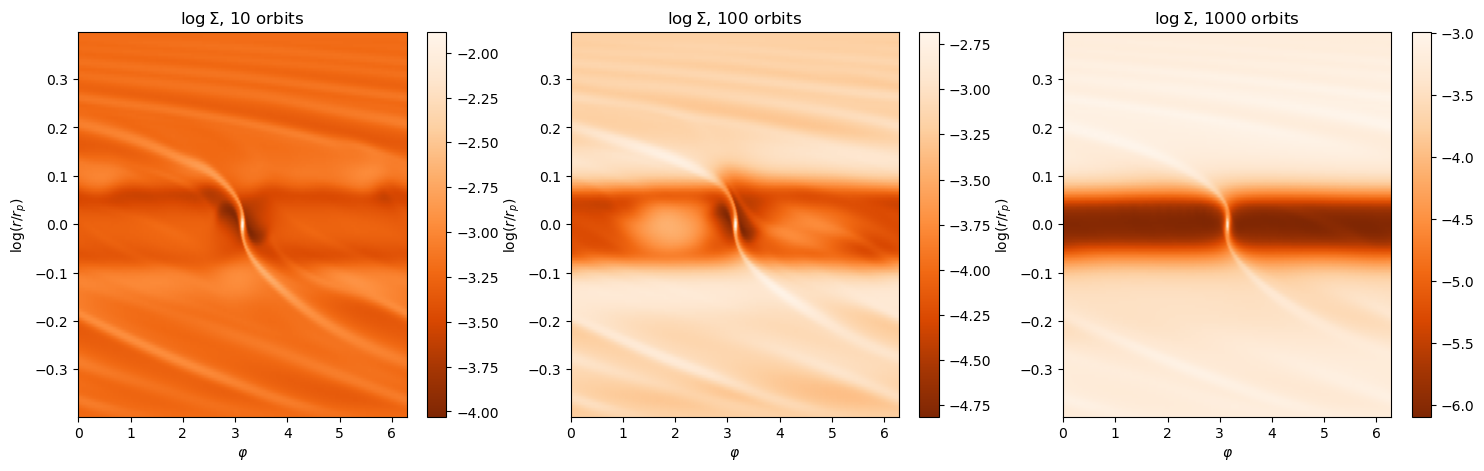

In [4]:
%matplotlib inline

frames = [1,10,100]
plt.figure(figsize=(len(frames)*6,5))


for i,frame in enumerate(frames):
    plt.subplot(1,len(frames),1+i)
    plt.imshow(np.log10(rho_cube[0][frame]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(0.4),np.log10(2.5)])
    plt.title(f"$\\log \\Sigma$, {frame*10} orbits")
    plt.colorbar()
    plt.xlabel("$\\varphi$")
    plt.ylabel("$\\log(r/r_p)$")


In [5]:
R_min = 0.4      
R_max = 2.5 
Nr = 128
Nphi = 384

r_list = np.fromfile(f"{path}domain_y.dat", sep="\n")[3:-4]#R_min * (R_max / R_min)**(np.linspace(0, 1, Nr))
phi = np.linspace(0, 2*np.pi, Nphi)

R, PHI = np.meshgrid(r_list, phi, indexing='ij')

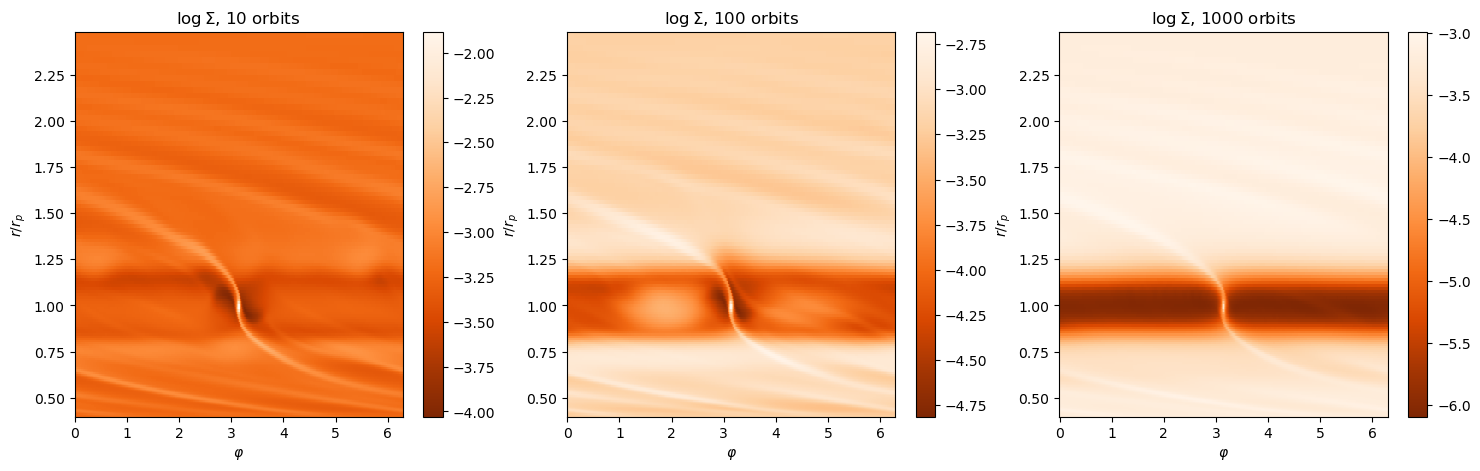

In [6]:
%matplotlib inline

frames = [1,10,100]
plt.figure(figsize=(len(frames)*6,5))


for i,frame in enumerate(frames):
    plt.subplot(1,len(frames),1+i)
    
    plt.pcolormesh(PHI, R, np.log10(rho_cube[0][frame]),cmap=cm.Oranges_r, shading='auto')
    plt.xlabel("$\\varphi$")
    plt.ylabel("$r/r_p$")
    plt.title(f"$\\log \\Sigma$, {frame*10} orbits")
    plt.colorbar()


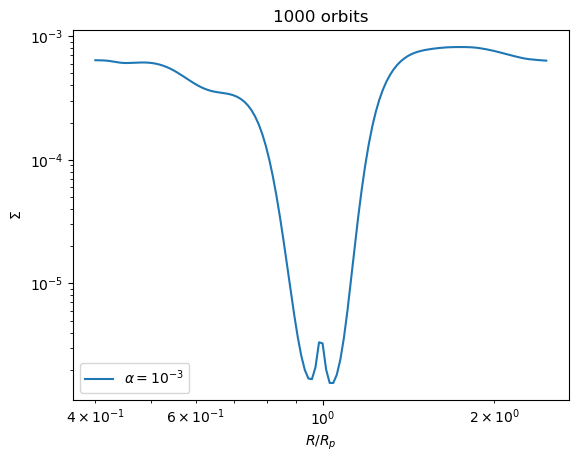

In [7]:

frame=100

rho_mean = np.mean(rho_cube, axis=3)

plt.plot(r_list,rho_mean[0][frame], label="$\\alpha=10^{-3}$")

plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frame*10} orbits")
plt.legend()

## Converting to cgs units

In [ ]:
# Some natural constants also used by radmc3d.
#
au  = 1.49598e13     # Astronomical Unit       [cm]
pc  = 3.08572e18     # Parsec                  [cm]
ms  = 1.98892e33     # Solar mass              [g]
ts  = 5.78e3         # Solar temperature       [K]
ls  = 3.8525e33      # Solar luminosity        [erg/s]
rs  = 6.96e10        # Solar radius            [cm]
ss  = 5.6703e-5      # Stefan-Boltzmann const  [erg/cm^2/K^4/s]
kk  = 1.3807e-16     # Bolzmann's constant     [erg/K]
mp  = 1.6726e-24     # Mass of proton          [g]
GG  = 6.67408e-08    # Gravitational constant  [cm^3/g/s^2]
pi  = np.pi          # Pi

#
# Star parameters
#
mstar    = 2.4*ms
rstar    = 2.4*rs
tstar    = 1e4
pstar    = np.array([0.,0.,0.])

# Turning this into a setup for radmc3d

You can also find this in `altered_setup.py`

In [ ]:
dust_to_gast = 0.01 # we just assume this dust-to-gas-mass ratio.

In [ ]:
import sys
# python won't find the helper files otherwise.
sys.path.append("/home/hd/hd_hd/hd_cu284/jupyter notebooks/run_ppdisk_fargo3d_1/")

import os

# Add the library path for libgfortran.so.5
os.environ['LD_LIBRARY_PATH'] = '/usr/lib64:' + os.environ.get('LD_LIBRARY_PATH', '')


In [ ]:
#
# Model setup for reading a 2-D (r,phi) model from FARGO3D with dust
# into RADMC-3D.
#
import numpy as np
import matplotlib.pyplot as plt
import readfargo as fg
from makedustopacfortran import create_dustkapscatmat_file
import os
from radmc3dPy.analyze import readOpac
from scipy.optimize import bisect
#
# A simple grid refinement function
#
def grid_refine_inner_edge(x_orig,nlev,nspan):
    x     = x_orig.copy()
    rev   = x[0]>x[1]
    for ilev in range(nlev):
        x_new = 0.5 * ( x[1:nspan+1] + x[:nspan] )
        x_ref = np.hstack((x,x_new))
        x_ref.sort()
        x     = x_ref
        if rev:
            x = x[::-1]
    return x
#
# Some natural constants
#
au  = 1.49598e13     # Astronomical Unit       [cm]
pc  = 3.08572e18     # Parsec                  [cm]
ms  = 1.98892e33     # Solar mass              [g]
ts  = 5.78e3         # Solar temperature       [K]
ls  = 3.8525e33      # Solar luminosity        [erg/s]
rs  = 6.96e10        # Solar radius            [cm]
ss  = 5.6703e-5      # Stefan-Boltzmann const  [erg/cm^2/K^4/s]
kk  = 1.3807e-16     # Bolzmann's constant     [erg/K]
mp  = 1.6726e-24     # Mass of proton          [g]
GG  = 6.67408e-08    # Gravitational constant  [cm^3/g/s^2]
pi  = np.pi          # Pi

#
# Star parameters
#
mstar    = 2.4*ms
rstar    = 2.4*rs
tstar    = 1e4
pstar    = np.array([0.,0.,0.])

#
# Read a FARGO3D frame
#
# NOTE: Set the dir variable to the simulation you wish to import, and
#       the itime to the time snapshot you are interested in. The FARGO3D
#       simulations are in dimensionless units. By setting r0 in cm (see below)
#       and mstar in gram (see above), the simulation becomes "physical"
#       with units in CGS.
#
path    = path
itime    = 100
r0       = 60*au    # The radius corresponding to '1' in dimensionless units
fargo    = fg.frame(itime,rhodust=True,dir=path)
fargo.convert_to_cgs(mstar,r0)
#fargo.show(q=fargo.sigma_gas_cgs)
#fargo.show(q=fargo.sigma_dust_cgs[0])



In [ ]:
# checking it was imported correctly
fargo.show()

But we don't actually want to use the full profile. Just the azimuthal average will do.

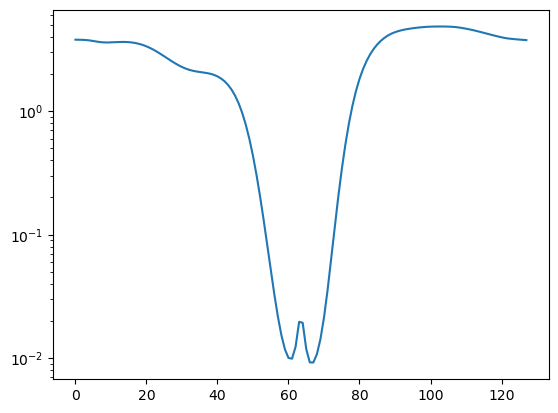

In [13]:
plt.plot(np.mean(fargo.sigma_gas_cgs, axis=1))
plt.yscale("log")

(128, 384)
(128, 384)


Text(0, 0.5, '$\\log(r/r_p)$')

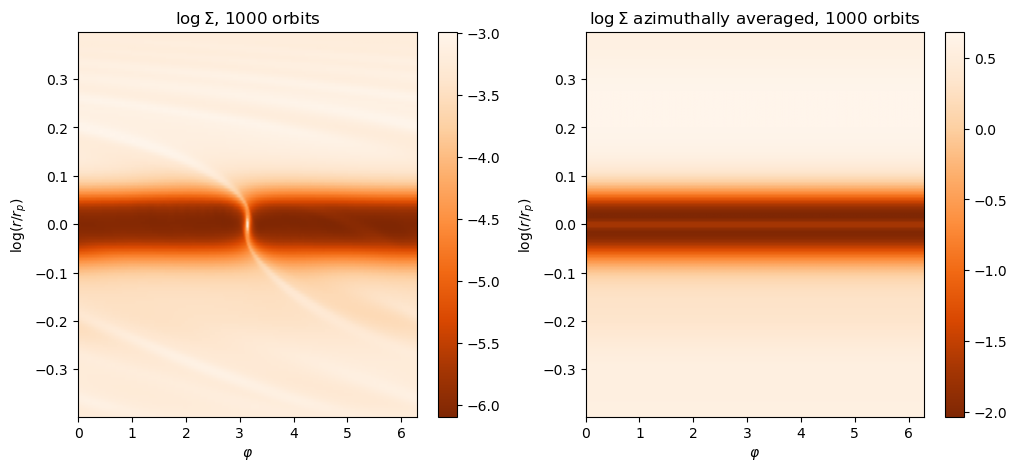

In [14]:
new_gasdens = np.outer(np.mean(fargo.sigma_gas_cgs, axis=1), np.ones(shape=len(fargo.sigma_gas_cgs[0])))
print(np.shape(new_gasdens))
print(np.shape(fargo.sigma_gas_cgs))


frame = 100
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(np.log10(rho_cube[0][frame]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(0.4),np.log10(2.5)])
plt.title(f"$\\log \\Sigma$, {frame*10} orbits")
plt.colorbar()
plt.xlabel("$\\varphi$")
plt.ylabel("$\\log(r/r_p)$")

plt.subplot(1,2,2)
plt.imshow(np.log10(new_gasdens), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(0.4),np.log10(2.5)])
plt.title(f"$\\log \\Sigma$ azimuthally averaged, {1000} orbits")
plt.colorbar()
plt.xlabel("$\\varphi$")
plt.ylabel("$\\log(r/r_p)$")

In [15]:
#
# The 1-st dust component for RADMC-3D will follow the gas component
# of FARGO3D. We assume that these grains are small enough that they
# are well-mixed with the gas, at least near the midplane. We specify
# the dust-to-gas ratio for this fine-grained dust with the dtg_smalldust
# parameter.
#
# Any dust components in FARGO3D will be _in_addition_ to this first
# component
#
# NOTE: Without any small-grain component, the dust geometry will become
#       very geometrically thin, which means that very little starlight
#       will be captured, and the disk will become very cold. However,
#       if at least one of the dust components is vertically extended
#       (i.e. small grains), then more stellar radiation is captured
#       and the re-emission of this radiation will then also make the
#       large dust grains at the midplane warmer. Observations of most
#       protoplanetary disks show that most of them have some small
#       dust vertically extended above the midplane even though other
#       dust appears to be near the midplane (see e.g. IM Lup,
#       with the small grains seen in scattered light with VLT-SPHERE,
#       Avenhaus et al. 2018, ApJ 863, 44, and large grains seen with
#       ALMA, Huang et al., 2018, APJ 869, 43).
#
dtg_smalldust  = 1e-2        # Dust to gas ratio for small dust following the gas
new_gasdens = np.outer(np.mean(fargo.sigma_gas_cgs, axis=1), np.ones(shape=len(fargo.sigma_gas_cgs[0])))
sigma_gas_2d   = new_gasdens#fargo.sigma_gas_cgs
sigma_dust_2d  = []
sigma_dust_2d.append(sigma_gas_2d*dtg_smalldust)  # First the gas-following small dust

#"""
#### THERE IS NO OTHER KINDS OF DUST IN THIS SIM ####
for d in fargo.sigma_dust_cgs:
    sigma_dust_2d.append(d)                       # Then the dynamic dust from FARGO3D multifluid
nrspec   = len(sigma_dust_2d)
print(f"{nrspec} dust species detected!")
#""" 

1 dust species detected!


In [16]:
#
# Make the RADMC-3D radial and phi grids
#

"""
I'm not 100% this is the correct way to do it for a logarithmic grid. But I assume the shift this
can cause is pretty small.

Nah, I think it's fine because the readfargo.py code has this line:

        self.r   = (r[3:-4]*r[4:-3])**0.5

That should work for log grids. On the other hand, phi gets

        self.phi = 0.5 * ( phi[:-1] + phi[1:] )

Which is correct for linear grids.
"""
ri       = 0.5*(fargo.r_cgs[1:]+fargo.r_cgs[:-1])
ri       = np.hstack([2*ri[0]-ri[1],ri,2*ri[-1]-ri[-2]])
rc       = 0.5 * ( ri[:-1] + ri[1:] )#np.sqrt(ri[:-1] * ri[1:])
nr       = len(rc)   # Recompute nr, because of refinement at inner edge
r        = rc        # The radial grid of the analytic disk model (below)
phii     = 0.5*(fargo.phi[1:]+fargo.phi[:-1])+np.pi
phii     = np.hstack([2*phii[0]-phii[1],phii,2*phii[-1]-phii[-2]])
phic     = 0.5 * ( phii[:-1] + phii[1:] )
nphi     = len(phic)
r_2d,phi_2d = np.meshgrid(rc,phic,indexing='ij')



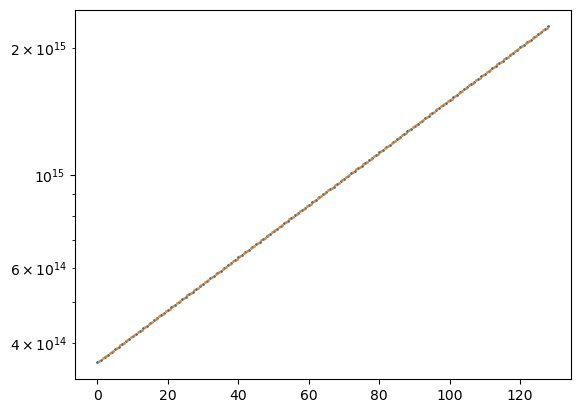

In [17]:
"""
#plt.figure(figsize=(20,20))
plt.scatter([i for i in range(len(ri))],ri, s=1)
plt.scatter([i+0.5 for i in range(len(rc))],rc, s=1)
plt.yscale("log")
"""

In [18]:
#
# Now make a simple analytical disk model roughly along the
# lines of Chiang & Goldreich (1997), but with just a single
# vertical layer and with a constant radiative incidence angle.
#

"""
How are the incidence angle and the flaring index/aspect ratio related?

The incidence angle is given by alpha = h/r -dh/dr (according to armitage's book). So it will depend on r for a flared disk!

Also, we're assuming here that the disk radiates as a black body and is vertially isothermal. (In particular there's no dust
in the way)

What is a reasonable value for flang?
It's not really self-consistent to choose a constant value for it . . .

"""

flang    = 0.05                        # The assumed constant radiative incidence angle
lstar    = 4*pi*rstar**2*ss*tstar**4   # Stellar luminosity
firr     = flang*lstar/(4*pi*r**2)     # Irradiative flux
tmid     = (firr/ss)**0.25             # Estimate of midplane temperature
cs       = np.sqrt(kk*tmid/(2.3*mp))   # Isothermal sound speed at midplane
omk      = np.sqrt(GG*mstar/r**3)      # The Kepler angular frequency
hp       = cs/omk                      # The pressure scale height
hpr      = hp/r                        # The dimensionless hp

#
# Compare the results to the AspectRatio and FlaringIndex of
# the FARGO3D setup. Note that we compute them using a simple
# Chiang & Goldreich like model, but this also has a free
# parameter: flang (the incidence angle). Since we keep this
# angle constant, the FlaringIndex should be 0.25, because
# T ~ r**(-1) --> c_s ~ r**(-0.5), and Omega_K ~ r**(-1.5),
# so H_p/r = c_s / (Omega_K * r) ~ r**(0.25).
#
AspectRatio  = np.interp(r0,r,hpr)     # The H_p/r at r=r0
flidx        = ( np.log(hpr) - np.log(AspectRatio) ) / ( np.log(r) - np.log(r0) )
FlaringIndex = np.interp(r0,r,flidx)   # The Flidx at r=r0
print('Please check that the RADMC-3D setup is roughly consistent with the FARGO3D setup:')
print('  AspectRatio in RADMC-3D model at R0  = {}'.format(AspectRatio))
print('  FlaringIndex in RADMC-3D model at R0 = {}'.format(FlaringIndex))
print('If these values are vastly different from those in the FARGO3D .par file,')
print('you should either modify the parameters in the RADMC-3D model, or the parameters')
print('in the FARGO3D model, to make them both mutually self-consistent.')


Please check that the RADMC-3D setup is roughly consistent with the FARGO3D setup:
  AspectRatio in RADMC-3D model at R0  = 0.08076501161365832
  FlaringIndex in RADMC-3D model at R0 = 0.24998798997829855
If these values are vastly different from those in the FARGO3D .par file,
you should either modify the parameters in the RADMC-3D model, or the parameters
in the FARGO3D model, to make them both mutually self-consistent.


Text(0, 0.5, 'hp/r (dimensionslos)')

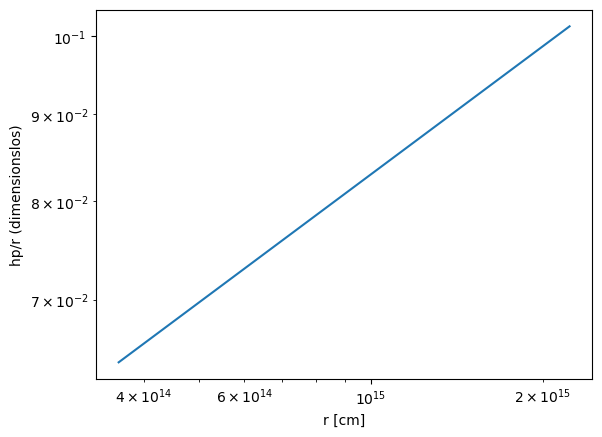

In [23]:
plt.plot(r,hpr)
plt.yscale("log")
plt.xscale("log")
plt.xlabel("r [cm]")
plt.ylabel("hp/r (dimensionslos)")

In [32]:
#
# Next we have to decide how to vertically distribute the dust.
# To do this self-consistently with the FARGO3D model, we have
# to apply Eq. (19) of Fromang & Nelson (2009) A&A 496, 597.
# The (Omega*tau_s)_mid in that equation is the Stokes number.
#
# In the standard FARGO3D model, you specify the inverse Stokes
# number of the dust grains, not the grain size. However, for
# the radiative transfer, we need the grain size, which we keep
# fixed everywhere, and the Stokes number should then be variable
# dependent on the Sigma_gas and T_gas. So you may need to
# modify FARGO3D to keep a_grain constant instead of Stokes.
# But you can also estimate roughly which grain size belongs
# to which Stokes number. Here, however, we specify the grain
# radius in micron.
#
# NOTE: These have to be consistent with the opacity files
#       dustkappa_xxxx.inp you specify. Also the material
#       density must be consistent with that of the material
#       of the dust in dustkappa_xxxx.inp.
#
# NOTE: Don't forget that the first grain size belongs to the
#       dust component that is assumed to follow the gas, i.e.
#       it should have small grain size (e.g. 0.1 micron).
#

"""
We assume only one dust species that follows the gas. 0.1 micron was chosen quite arbitrarily
"""
a_grains_mic= np.array([1e-1])#np.array([1e-1,1e2,1e3,1e4])    # Grain radii in micron
a_grains    = a_grains_mic*1e-4          # Grain radii in cm
xi_grains   = 3.7                        # Grain material density in g/cm^3
m_grains    = (4*np.pi/3)*xi_grains*a_grains**3  # Grain masses
s_grains    = np.pi*a_grains**2                  # Grain cross sections
assert nrspec==len(a_grains), "Error: The number of grain sizes is unequal to the number of dust components in FARGO3D (Note: the first dust component follows the gas, so if your FARGO3D simulation has 2 dust components, in RADMC-3D we have 3 dust components."

#
# We now compute the Stokes number of these grains at the
# midplane, based on the gas density and the temperature
#
omk_2d      = np.sqrt(GG*mstar/r_2d**3)  # The Kepler frequency Omega_K in 1/s
cs_2d,dum   = np.meshgrid(cs,phic,indexing='ij')  # The isothermal sound speed c_s in cm/s
hp_2d       = cs_2d/omk_2d               # The press scale height H_p = c_s / Omega_K in cm
hpr_2d      = hp_2d/r_2d                 # The aspect ratio H_p / r
vth_2d      = np.sqrt(8/np.pi)*cs_2d     # The thermal velocity of H2 gas particles in cm/s
rho_gas_mid_2d = sigma_gas_2d/(np.sqrt(2*pi)*hp_2d)  # Midplane gas density in g/cm^3
Stokes_mid_2d = []
for m,s in zip(m_grains,s_grains):
    # s_grains is the cross section of the grain, NOT THE RADIUS!
    St = (3./4.)*(m/s)*omk_2d/(rho_gas_mid_2d*vth_2d)  # Stokes number assuming Epstein drag law
    Stokes_mid_2d.append(St)
#
# Compute an estimate of the mean free path of the gas molecules, to be
# able to check if the Epstein regime is justified
#
mugas        = 2.3                       # Mean molecular gas in a protoplanetary disk in mp units
n_gas_mid_2d = rho_gas_mid_2d/(mugas*mp) # Number density of gas particles
siggas       = 2e-15                     # Cross section of H2 molecule (assume that to be for all gas molecules)
lmfp         = 1 / (n_gas_mid_2d*siggas) # Mean free path of the gas molecules
assert (a_grains.max()/lmfp).max()<1, "Warning: Epstein regime not everywhere valid"


In [33]:
#
# Compute the turbulent viscosity in CGS units
#
nu_fargo     = 1e-5                              # NOTE: This should be the one from the .par file of FARGO3D
nu_cgs       = nu_fargo * np.sqrt(GG*mstar*r0)   # Turbulent viscosity in cm^2/s
alpha_turb   = nu_cgs/(cs**2/omk)                # Just for fun: what would the turbulent alpha be?
D_cgs        = nu_cgs                            # We assume the diffusion by turbulence = viscosity by turbulence


In [34]:
%env LD_LIBRARY_PATH=/usr/lib64:$LD_LIBRARY_PATH


env: LD_LIBRARY_PATH=/usr/lib64:$LD_LIBRARY_PATH


In [35]:
"""
Despite my best efforts, this just doesn't want to run inside a jupyter notebook. I've copied all the code into
the altered_setup.py file, where it works just fine. Whatever.
"""

#
# Write the wavelength_micron.inp file
#
lam1     = 0.1e0
lam2     = 7.0e0
lam3     = 25.e0
lam4     = 1.0e4
n12      = 20
n23      = 100
n34      = 30
lam12    = np.logspace(np.log10(lam1),np.log10(lam2),n12,endpoint=False)
lam23    = np.logspace(np.log10(lam2),np.log10(lam3),n23,endpoint=False)
lam34    = np.logspace(np.log10(lam3),np.log10(lam4),n34,endpoint=True)
lam      = np.concatenate([lam12,lam23,lam34])
nlam     = lam.size
#
# Write the wavelength file
#
with open('wavelength_micron.inp','w+') as f:
    f.write('%d\n'%(nlam))
    for value in lam:
        f.write('%13.6e\n'%(value))

#
# Make sure that the dust opacity files have been created properly
#
sizeformat      = "8.2e"     # Format of the grain size in the filenames
species         = "olivine"  # Name of the optical constants file for olivine: olivine.lnk
errortol        = 1e99       # The errors come from super-forward-scattering. With chopping we fix that.
chopangle       = 5.         # The chopping angle cone.

remakeopacs     = True
if(os.path.isfile("dustspecies.inp")):
    with open("dustspecies.inp","r") as f:
        if(f.readline().strip()==species):
            remakeopacs = False
if remakeopacs:
    os.system('rm -f dustkap*.inp')
with open("dustspecies.inp","w") as f:
    f.write(species+"\n")
for acm in a_grains:
    amic = acm*1e4
    astr = ('{0:'+sizeformat+'}').format(amic).strip()
    opacfilename = 'dustkapscatmat_'+astr+'.inp'
    if(not os.path.isfile(opacfilename)):
        astr = ("{0:"+sizeformat+"}").format(amic)
        print("Creating opacity for grain size "+astr+" micron radius")
        create_dustkapscatmat_file(amic,species,sizeformat=sizeformat, \
                                   errortol=errortol,chopangle=chopangle)


Creating opacity for grain size 1.00e-01 micron radius


./makeopac_smoothed: error while loading shared libraries: libgfortran.so.5: cannot open shared object file: No such file or directory


In [42]:
#
# Estimate the maximum vertical thickness of the disk based on the
# radial path of the stellar light, and focusing only on the smallest
# dust grains, and assuming no settling. This calculation is done to
# estimate the required vertical extent of the theta-grid.
#
def ftauroot(theta,tau0,ri,sg,hpr,kap):
    rho   = (sg/(np.sqrt(2*pi)*hpr*r))*np.exp(-0.5*((np.pi/2-theta)/hpr)**2)
    dr    = ri[1:]-ri[:-1]
    tau   = kap*(rho*dr).sum()
    return tau-tau0

sigma_smalldust = sigma_dust_2d[0]
astr            = ("{0:"+sizeformat+"}").format(a_grains[0]*1e4)
osmall          = readOpac(ext=astr,scatmat=True)
lamstar         = 0.45   # Representative wavelength for stellar radiation
kappa           = np.interp(lamstar,osmall.wav[0],osmall.kabs[0]+osmall.ksca[0])

thetaupp        = np.zeros(nphi)
for iphi in range(nphi):
    args           = (0.01,ri,sigma_smalldust[:,iphi],hpr,kappa)
    thetaupp[iphi] = bisect(ftauroot, 0.2, np.pi/2, args=args, xtol=1e-6, rtol=1e-6)
thetaup         = thetaupp.min()   # Min, because pi/2-thetaup must be max

#
# Make the theta coordinate, and refine near the midplane
# (to resolve the dust layer)
#
# NOTE: If your grains have not-so-large Stokes numbers,
#       you can save computing time by reducing nlev_zr.
#       Just make sure that the vertical structure of the
#       distribution of the largest grains remains resolved
#       by the theta-grid.
#
ntheta   = 32
thetai   = np.linspace(thetaup,0.5e0*np.pi,ntheta+1)
zr       = thetai[::-1]
nlev_zr  = 7         # Grid refinement at the midplane: nr of cycles
nspan_zr = 3         # Grid refinement at the midplane: nr of cells each cycle
zr       = grid_refine_inner_edge(zr,nlev_zr,nspan_zr)
thetai   = zr[::-1]
thetac   = 0.5 * ( thetai[:-1] + thetai[1:] )
ntheta   = len(thetac)


Reading dustkapscatmat_1.00e-01.inp


In [44]:
#
# Make the 3-D grid
#
qq       = np.meshgrid(rc,thetac,phic,indexing='ij')
rr       = qq[0]
tt       = qq[1]
pp       = qq[2]
zr       = np.pi/2.e0 - qq[1]

#
# For later vertical normalization: the Delta z
# (we integrate along theta, i.e. not exactly vertical)
#
dz       = zr[:,:-1,:]*rr[:,:-1,:]-zr[:,1:,:]*rr[:,1:,:]

#
# Expand the 2-D gas model to 3-D
#
sigma_gas_3d  = np.zeros_like(rr)
hh_3d         = np.zeros_like(rr)
hhr_3d        = np.zeros_like(rr)
for it in range(ntheta):
    sigma_gas_3d[:,it,:] = sigma_gas_2d[:,:]
    hh_3d[:,it,:]        = hp_2d[:,:]
    hhr_3d[:,it,:]       = hpr_2d[:,:]
rho_gas_3d = ( sigma_gas_3d / (np.sqrt(2.e0*np.pi)*hh_3d) ) * np.exp(-(zr**2/hhr_3d**2)/2.e0)
zhpr2_3d   = zr**2/hhr_3d**2

#
# Now do the same for the dust. Use Eq. (19) of Fromang & Nelson (2009) A&A 496, 597.
#
rho_dust_3d = []
for St,Sig in zip(Stokes_mid_2d,sigma_dust_2d):
    #
    # Make things 3D
    #
    sigma_dust_3d  = np.zeros_like(rr)
    St_3d          = np.zeros_like(rr)
    D_3d           = np.zeros_like(rr)
    for it in range(ntheta):
        sigma_dust_3d[:,it,:] = Sig[:,:]
        St_3d[:,it,:]         = St[:,:]
        D_3d[:,it,:]          = D_cgs/(cs_2d*hp_2d)   # Dimensionless diffusion coefficient
    #
    # Now use Fromang & Nelson's formula
    #
    #rho = np.exp(-(St_3d/D_3d)*(np.exp(zhpr2_3d*0.5)-1)-zhpr2_3d*0.5)
    """
    Since I have no intuition for that formula, let's stick with just being proportional to the gas.
    """
    rho = ( sigma_dust_3d / (np.sqrt(2.e0*np.pi)*hh_3d) ) * np.exp(-(zr**2/hhr_3d**2)/2.e0)

    """
    #
    # Compute the vertical integral
    #
    rhoav = 0.5*(rho[:,:-1,:]+rho[:,1:,:])
    dum   = (rhoav*dz).sum(axis=1)
    #
    # Now normalize the dust distribution such that the vertical
    # integral equals the dust surface density sigma_dust_3d
    #
    norm  = np.zeros_like(rr)
    for it in range(ntheta):
        norm[:,it,:]          = dum[:,:]
    if thetac.max()<=np.pi/2:
        norm *= 2  # Two sides
    norm  = sigma_dust_3d/norm
    rho  *= norm
    #
    # Add this dust component to the list
    #
    """
    rho_dust_3d.append(rho)
    
#
# Monte Carlo parameters
#
nphot_therm    = 1000000000
nphot_scat     = 10000000

#
#
# Write the stars.inp file
#
with open('stars.inp','w+') as f:
    f.write('2\n')
    f.write('1 %d\n\n'%(nlam))
    f.write('%13.6e %13.6e %13.6e %13.6e %13.6e\n\n'%(rstar,mstar,pstar[0],pstar[1],pstar[2]))
    for value in lam:
        f.write('%13.6e\n'%(value))
    f.write('\n%13.6e\n'%(-tstar))
#
# Write the grid file
#
with open('amr_grid.inp','w+') as f:
    f.write('1\n')                       # iformat
    f.write('0\n')                       # AMR grid style  (0=regular grid, no AMR)
    f.write('100\n')                     # Coordinate system: spherical
    f.write('0\n')                       # gridinfo
    f.write('1 1 1\n')                   # Include r,theta,phi coordinates
    f.write('%d %d %d\n'%(nr,ntheta,nphi))  # Size of grid
    for value in ri:
        f.write('%13.6e\n'%(value))      # X coordinates (cell walls)
    for value in thetai:
        f.write('%17.10e\n'%(value))     # Y coordinates (cell walls) (use higher precision here)
    for value in phii:
        f.write('%13.6e\n'%(value))      # Z coordinates (cell walls)
#
# Write the density file
#
with open('dust_density.inp','w+') as f:
    f.write('1\n')                       # Format number
    f.write('%d\n'%(nr*ntheta*nphi))     # Nr of cells
    f.write('{}\n'.format(nrspec))       # Nr of dust species
    for rhod in rho_dust_3d:
        data = rhod.ravel(order='F')   # Create a 1-D view, fortran-style indexing
        data.tofile(f, sep='\n', format="%13.6e")
        f.write('\n')
#
# Dust opacity control file
#
with open('dustopac.inp','w+') as f:
    f.write('2               Format number of this file\n')
    f.write('{}               Nr of dust species\n'.format(nrspec))
    f.write('============================================================================\n')
    for agr in a_grains_mic:
        f.write('10              Way in which this dust species is read\n')
        f.write('0               0=Thermal grain\n')
        f.write(('{0:'+sizeformat+'}        Extension of name of dustkapscatmat_***.inp file\n').format(agr))
        f.write('----------------------------------------------------------------------------\n')
#
# Write the radmc3d.inp control file
#
with open('radmc3d.inp','w+') as f:
    f.write('nphot_therm = %d\n'%(nphot_therm))
    f.write('nphot_scat = %d\n'%(nphot_scat))
    f.write('scattering_mode_max = 1\n')
    f.write('iranfreqmode = 1\n')
